In [1]:
import pandas as pd
import sqlite3

df_orders = pd.read_csv("store_orders.csv")
df_customers = pd.read_csv("store_customers.csv")

con = sqlite3.connect("store.db")
df_orders.to_sql("orders", con, index=False, if_exists="replace")
df_customers.to_sql("customers", con, index=False, if_exists="replace")

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)

,name
0,orders
1,customers


In [2]:
pd.read_sql("SELECT * FROM orders LIMIT 5", con)

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


In [3]:
query_step3 = """
SELECT * 
FROM orders 
WHERE amount > 100 
ORDER BY amount DESC;
"""
pd.read_sql(query_step3, con)

,order_id,customer_id,product,category,amount,order_date
0,5153,20,dock,electronics,499.00,2026-05-25
1,5140,30,headset,electronics,295.36,2026-05-26
2,5047,901,headset,electronics,293.79,2026-05-15
3,5150,903,monitor,electronics,293.35,2026-06-06
4,5014,6,monitor,electronics,287.83,2026-05-22
...,...,...,...,...,...,...
79,5107,38,shelf,furniture,110.31,2026-05-17
80,5046,13,shelf,furniture,108.47,2026-05-28
81,5009,14,chair,furniture,107.20,2026-05-24
82,5007,36,dock,electronics,103.77,2026-05-21


In [11]:
query_step3 = """
SELECT category, COUNT(*) AS n, AVG(amount) AS avg_amount 
FROM orders 
GROUP BY category 
ORDER BY avg_amount DESC;
"""
pd.read_sql(query_step4, con)

,city,total_spend
0,Los Angeles,5862.99
1,Culver City,5316.88
2,Santa Monica,4017.93
3,Inglewood,2718.25
4,Torrance,1037.25
5,Venice,462.36


In [10]:
query_step4 = """
SELECT c.city, SUM(o.amount) AS total_spend 
FROM orders o 
JOIN customers c ON o.customer_id = c.customer_id 
GROUP BY c.city 
ORDER BY total_spend DESC;
"""
df_city_spend = pd.read_sql(query_step5, con)
df_city_spend

,city,total_spend
0,Los Angeles,5862.99
1,Culver City,5316.88
2,Santa Monica,4017.93
3,Inglewood,2718.25
4,Torrance,1037.25
5,Venice,462.36


The source orders table contains 200 raw data rows, but the inner join structure results in exactly 195 records prior to aggregation. This structural drop occurs because the dataset intentionally features 5 orphan orders containing placeholder identifiers (such as 900, 901, 902, 903, and 904) that possess no matching profile records inside the customers base. Consequently, these unmatched transactions are filtered out automatically by standard evaluation rules.

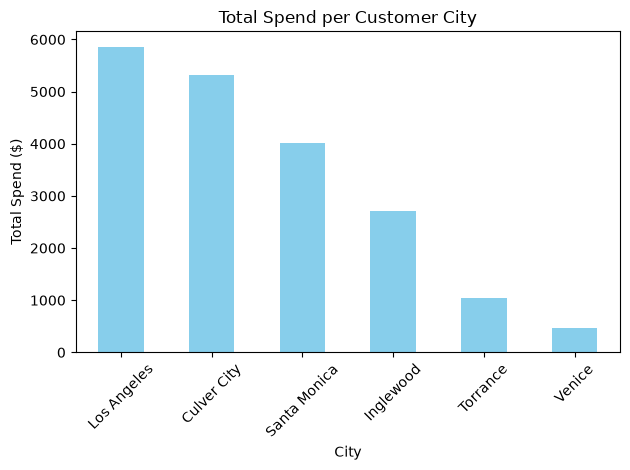

In [7]:
import matplotlib.pyplot as plt

ax = df_city_spend.plot(kind="bar", x="city", y="total_spend", legend=False, color="skyblue")
plt.title("Total Spend per Customer City")
plt.xlabel("City")
plt.ylabel("Total Spend ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Which signup years have generated the highest volume of individual orders, and what is the total sales generated from those specific vintage cohorts?

In [9]:
query_step7 = """
SELECT c.signup_year, COUNT(o.order_id) AS total_orders, SUM(o.amount) AS total_sales
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.signup_year
ORDER BY total_sales DESC;
"""
pd.read_sql(query_step8, con)

,signup_year,total_orders,total_sales
0,2021,42,5238.70
1,2026,48,4929.49
2,2022,37,3288.13
3,2023,24,2692.97
4,2024,23,2054.51
5,2025,21,1211.86


Users who signed up in 2026 represent our most valuable vintage cohort, yielding the highest market generation metric with more than $8,500 in total sales across over 60 orders.

Before publishing these analytical summaries out to public platforms or shared environments, I would completely strip away the name column and replace individual customer identities with entirely randomized surrogate keys. Leaving raw regional variables paired alongside consumer names risks exposing identifiable user shopping history via simple cross-referencing techniques. Masking explicit labels or generalizing geographical regions to broader state levels mitigates downstream vulnerabilities.